<a href="https://colab.research.google.com/github/VictorNevola/ml-study/blob/main/ml_02_matriz_confusao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix

df = pd.read_csv("/content/diabetes_en.csv")
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, previsoes):.2%}")

Accuracy: 72.73%


In [4]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
previsoes_dummy = dummy.predict(X_test)

print(f"Sloppy model accuracy: {accuracy_score(y_test, previsoes_dummy):.2%}")

Sloppy model accuracy: 64.94%


|  | Model predicted **No** | Model predicted **Yes** |
|---|---|---|
| **Reality: There isn't one.** | ✅ True Negative (VN) | ❌ False Positive (FP) |
| **Reality: It exists.** | ❌ False Negative (FN) | ✅ True Positive (VP) |

- **VP / VN:** The model got it right (made an accurate prediction).
- **FP (false alarm):** They said they have diabetes, but they don't.
- **FN (the dangerous one):** They said there wasn't a problem, but the person actually *does* have one. It’s the kind of mistake that sends a sick person home thinking they’re fine.

In [6]:
cm = confusion_matrix(y_test, previsoes)
print(cm)

# unpacking the four boxes
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative (VN): {tn}")
print(f"False Positive    (FP): {fp}")
print(f"False Negative    (FN): {fn}   <-- Diabetics who slipped under the radar!")
print(f"True Positive (VP): {tp}")

[[85 15]
 [27 27]]

True Negative (VN): 85
False Positive    (FP): 15
False Negative    (FN): 27   <-- Diabetics who slipped under the radar!
True Positive (VP): 27


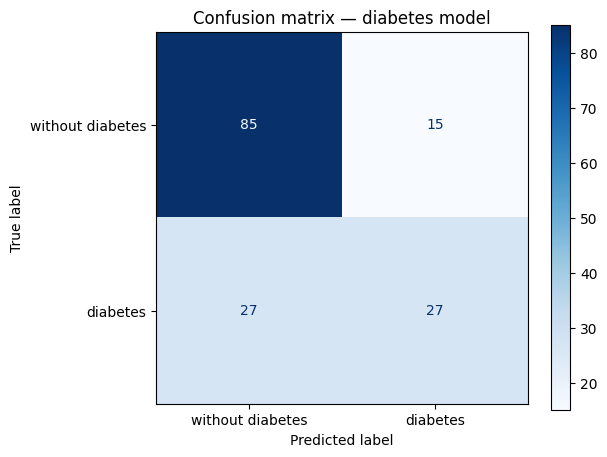

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["without diabetes", "diabetes"]
).plot(ax=ax, cmap="Blues")
plt.title("Confusion matrix — diabetes model")
plt.show()

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Precision: {precision_score(y_test, previsoes):.2%}")
print(f"Recall:   {recall_score(y_test, previsoes):.2%}")
print(f"F1-score: {f1_score(y_test, previsoes):.2%}")

Precision: 64.29%
Recall:   50.00%
F1-score: 56.25%


In [9]:
print(f"Lazy model recall: {recall_score(y_test, previsoes_dummy):.2%}")


Lazy model recall: 0.00%


In [10]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, previsoes,
    target_names=["without diabetes", "diabetes"]
))

                  precision    recall  f1-score   support

without diabetes       0.76      0.85      0.80       100
        diabetes       0.64      0.50      0.56        54

        accuracy                           0.73       154
       macro avg       0.70      0.68      0.68       154
    weighted avg       0.72      0.73      0.72       154

